1. Imports e Leitura

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/orders.csv")
df.head()

,id,order_number,channel,customer_id,salesperson_id,location_id,status,subtotal,discount_amount,total,placed_at,created_at,updated_at
0,1,SO-000001,ecommerce,1136,NaN,1,paid,323.34,35.57,287.77,2022-09-06 05:37:37,2022-09-06 05:37:37,2022-09-06 05:37:37
1,2,SO-000002,ecommerce,618,9.0,4,paid,53199.05,0.00,53199.05,2023-02-03 04:36:21,2023-02-03 04:36:21,2023-02-03 04:36:21
2,3,SO-000003,pos,227,10.0,4,confirmed,17157.39,0.00,17157.39,2024-12-30 07:15:17,2024-12-30 07:15:17,2024-12-30 07:15:17
3,4,SO-000004,ecommerce,1123,NaN,3,paid,11095.62,665.74,10429.88,2024-03-12 20:39:36,2024-03-12 20:39:36,2024-03-12 20:39:36
4,5,SO-000005,ecommerce,426,9.0,2,confirmed,32842.03,0.00,32842.03,2020-03-27 13:52:12,2020-03-27 13:52:12,2020-03-27 13:52:12


2. Visão Geral

In [2]:
n_rows, n_cols = df.shape
print(f"Total de linhas: {n_rows}")
print(f"Total de colunas: {n_cols}")

df["created_at"] = pd.to_datetime(df["created_at"])
print(f"Data mínima: {df['created_at'].min()}")
print(f"Data máxima: {df['created_at'].max()}")

Total de linhas: 48998
Total de colunas: 13
Data mínima: 2020-01-01 01:19:28
Data máxima: 2026-12-31 23:43:09


3. Estatísticas de Total

In [3]:
print(f"Mínimo: {df['total'].min()}")
print(f"Máximo: {df['total'].max()}")
print(f"Média: {df['total'].mean()}")

df["total"].describe()

Mínimo: 32.62
Máximo: 127262.02
Média: 28704.992077227642


count     48998.000000
mean      28704.992077
std       19425.636818
min          32.620000
25%       13171.235000
50%       25917.840000
75%       40941.882500
max      127262.020000
Name: total, dtype: float64

4. Checagem de Nulos e Inconsistëncias

In [4]:
print("Nulos por coluna:")
print(df.isnull().sum())

print("\nLinhas com total <= 0:")
print((df["total"] <= 0).sum())

print("\nValores únicos de status:")
print(df["status"].value_counts())

Nulos por coluna:
id                     0
order_number           0
channel                0
customer_id            0
salesperson_id     24131
location_id            0
status                 0
subtotal               0
discount_amount        0
total                  0
placed_at              0
created_at             0
updated_at             0
dtype: int64

Linhas com total <= 0:
0

Valores únicos de status:
status
paid         34365
confirmed     7335
cancelled     4847
draft         2451
Name: count, dtype: int64


5. Outliers

Q1: 13171.24 | Q3: 40941.88 | IQR: 27770.65
Limite superior: 82597.85
Qtd de outliers acima do limite: 452


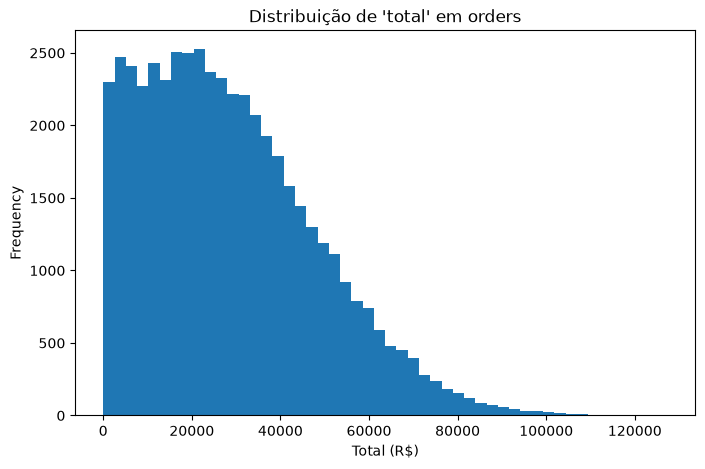

In [10]:
q1 = df["total"].quantile(0.25)
q3 = df["total"].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
lower_fence = q1 - 1.5 * iqr

print(f"Q1: {q1:.2f} | Q3: {q3:.2f} | IQR: {iqr:.2f}")
print(f"Limite superior: {upper_fence:.2f}")
print(f"Qtd de outliers acima do limite: {(df['total'] > upper_fence).sum()}")

df["total"].plot(kind="hist", bins=50, figsize=(8,5))
plt.title("Distribuição de 'total' em orders")
plt.xlabel("Total (R$)")
plt.show()

6. Checagens para reforçar o diagnóstico

In [9]:
# 1. Nulo de salesperson_id por canal
print("Nulos de salesperson_id por canal:")
print(df.groupby("channel")["salesperson_id"].apply(lambda x: x.isnull().mean()))

# 2. Consistência aritmética subtotal - discount = total
inconsistentes = df[(df["subtotal"] - df["discount_amount"] - df["total"]).abs() > 0.01]
print(f"\nLinhas com subtotal - discount != total: {len(inconsistentes)}")

# 3. Duplicidade de chave
print(f"\nIDs duplicados: {df['id'].duplicated().sum()}")
print(f"order_number duplicados: {df['order_number'].duplicated().sum()}")

Nulos de salesperson_id por canal:
channel
ecommerce    0.702667
pos          0.000000
Name: salesperson_id, dtype: float64

Linhas com subtotal - discount != total: 0

IDs duplicados: 0
order_number duplicados: 0


7. Achados
- A tabela orders contém 48.998 registros e 13 colunas, cobrindo o período de 01/01/2020 a 31/12/2026. A coluna total varia de R$32,62 a R$127.262,02, com média de R$28.704,99. A análise por IQR aponta valores acima de aproximadamente R$82.600 como outliers estatísticos, mas dado o perfil de varejo náutico (de acessórios a motores e embarcações), isso é compatível com a diversidade real de ticket, não necessariamente erro. A tabela é estruturalmente íntegra: não há duplicidade na chave id nem no order_number, e a relação subtotal - discount_amount = total é consistente em 100% das linhas. O único campo com nulos relevantes é salesperson_id, ausente em cerca de 70% dos pedidos do canal e-commerce e em 0% dos pedidos do canal pos, o que é coerente com o processo de negócio e não representa um problema de qualidade. Um ponto de atenção mais relevante para uso da tabela é que aproximadamente 15% dos pedidos estão em status cancelled ou draft, o que significa que qualquer análise de receita precisa necessariamente filtrar por status = 'paid' (ou equivalente), sob risco de inflar o faturamento real. A conclusão é que a tabela orders, isoladamente, está estruturalmente pronta para análises (sem duplicidade, sem inconsistência aritmética, poucos nulos e todos explicáveis por regra de negócio), mas ainda depende do filtro correto de status e do cruzamento com payments e fiscal_invoices para validar que o valor foi de fato recebido antes de ser usado em relatórios financeiros.

- Valor médio de total: R$ 28.704,99